In [1]:
%load_ext autoreload
%autoreload 2

# Step 0: Data init

In [2]:
from poremind import create_analysis_object

In [3]:
sample_paths = {
    'A8': 'example_data\A8_20240628_0009.abf',
    'A16': 'example_data\A16_20240417_0006.abf'
}
sample_to_group = {
    'A8': 'A8',
    'A16': 'A16',
}
analysis = create_analysis_object(sample_paths, sample_to_group=sample_to_group, reader='abf').load()

# Step 1: Denoise

In [4]:
# butterworth_filtfilt
analysis.denoise()

MultiSampleAnalysis(sample_paths={'A8': 'example_data\\A8_20240628_0009.abf', 'A16': 'example_data\\A16_20240417_0006.abf'}, sample_to_group={'A8': 'A8', 'A16': 'A16'}, reader='abf', reader_kwargs={}, traces={'A8__ch0_sw0': Trace(current=array([-147.7051, -147.7051, -146.7896, ...,   -1.8311,    0.9155,
         -1.5259], shape=(82887168,)), sampling_rate_hz=100000.0, time=array([  0.    ,   0.    ,   0.    , ..., 828.8717, 828.8717, 828.8717],
      shape=(82887168,)), source='example_data\\A8_20240628_0009.abf', channel=0, sweep=0), 'A8__ch1_sw0': Trace(current=array([-29.9683, -30.0293, -29.9988, ...,  -0.0305,   0.061 ,   0.0305],
      shape=(82887168,)), sampling_rate_hz=100000.0, time=array([  0.    ,   0.    ,   0.    , ..., 828.8717, 828.8717, 828.8717],
      shape=(82887168,)), source='example_data\\A8_20240628_0009.abf', channel=1, sweep=0), 'A16__ch0_sw0': Trace(current=array([-152.8931, -153.1982, -153.1982, ...,    0.3052,    0.3052,
          0.6104], shape=(90599808,))

In [5]:
# preview signal with time series
analysis.preview_signal(next(iter(analysis.traces.keys())), start_s=0.0, end_s=0.002).head()

,time,current
0,0.00000,-147.598602
1,0.00001,-147.347205
2,0.00002,-147.113445
3,0.00003,-146.910641
4,0.00004,-146.751388


In [6]:
# sample keys of different samples traces
analysis.traces.keys()

dict_keys(['A8__ch0_sw0', 'A8__ch1_sw0', 'A16__ch0_sw0', 'A16__ch1_sw0'])

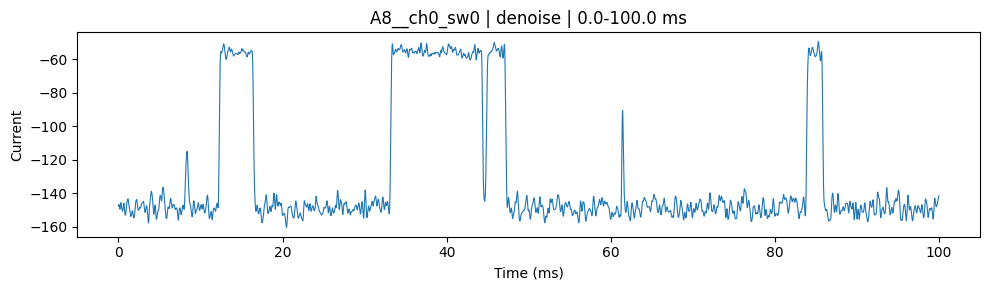

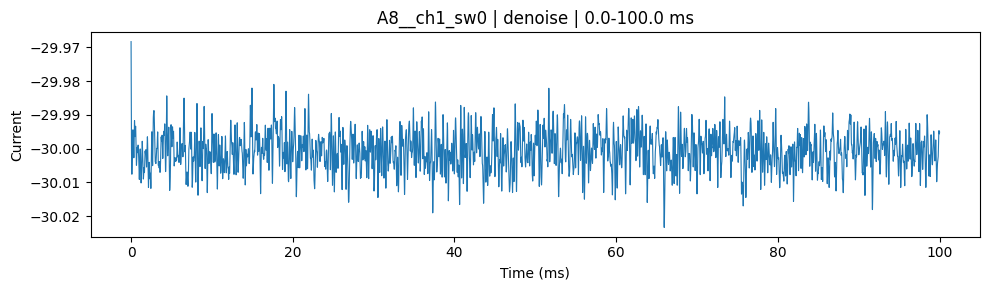

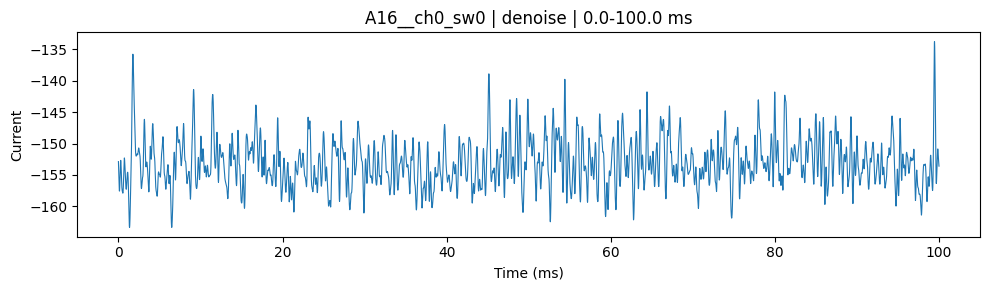

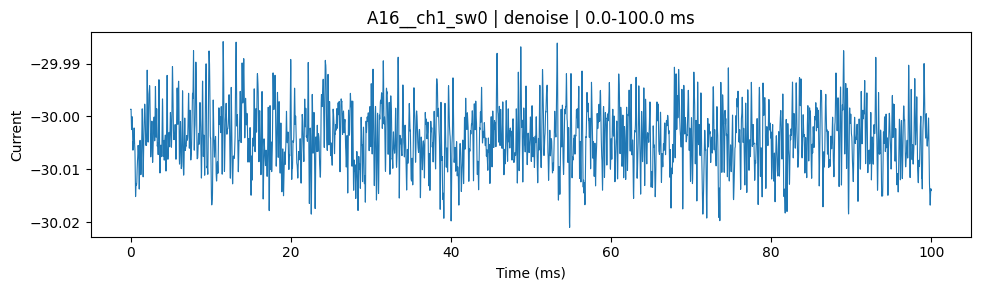

In [7]:
# plot the current trace of each sample with the select time window
for sample_id in analysis.traces.keys():
    analysis.pl.current(sample_id=sample_id, current='denoise', start_ms=0.0, end_ms=100.0, width=10, height=3) # current can set to 'raw' or 'denoise'

<Axes: title={'center': 'A8__ch0_sw0 | denoise | 20000-30000 ms'}, xlabel='Time (ms)', ylabel='Current'>

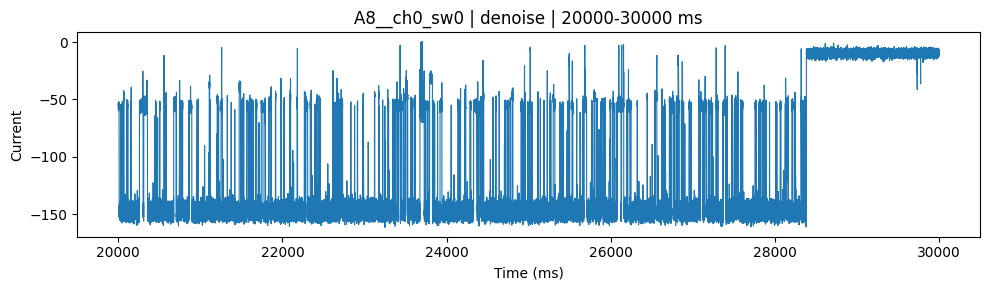

In [8]:
analysis.pl.current(sample_id="A8__ch0_sw0", current='denoise', start_ms=20000, end_ms=30000, width=10, height=3)

# Step 2: Event detection

In [ ]:
# simple event detection whithin the select time window for parameters tuning
analysis.detect_events_simple(detect_method='threshold',  # threshold / zscore_threshold / cusum / pelt / hmm
                              detect_params={'sigma_k': 4.0, 'min_duration_s': 0}, 
                              baseline_method='rolling_quantile', 
                              baseline_params={'window': 10000, 'q': 0.1},
                              detect_direction="up",
                              exclude_current=False,
                              start_ms=0,
                              end_ms=10000)

In [34]:
import pandas as pd

pd.DataFrame(analysis.simple_events["A8__ch0_sw0"]).head()

,start_idx,end_idx,baseline_local,delta_i,dwell_time_s,snr
0,819,850,-152.469011,-32.650223,0.00031,-0.822399
1,1224,1655,-152.728617,-93.806247,0.00431,-2.362807
2,3313,4446,-153.003851,-96.186498,0.01133,-2.422762
3,4478,4728,-153.064916,-92.265113,0.00250,-2.323989
4,6133,6159,-153.079114,-47.234821,0.00026,-1.189759


<Axes: title={'center': 'Simple events | A8__ch0_sw0 | denoise | event 1-10'}, xlabel='Time (ms)', ylabel='Current'>

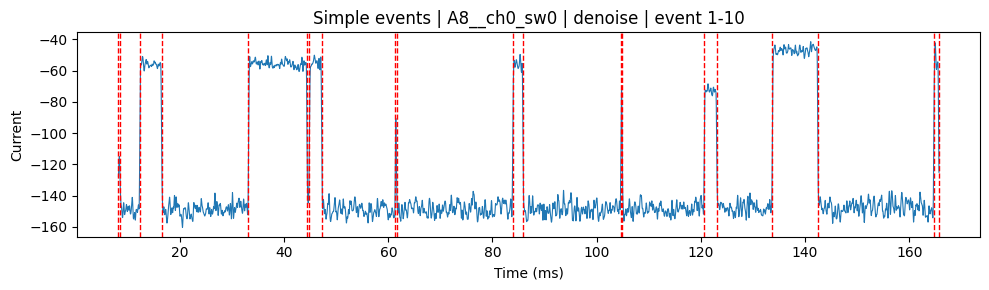

In [35]:
analysis.plot.event_current_simple(sample_id="A8__ch0_sw0", current="denoise", start_event=1, end_event=10)

In [9]:
# final event detection with the tuned parameters for all traces
analysis = analysis.detect_events(detect_method='threshold',  # threshold / zscore_threshold / cusum / pelt / hmm
                                detect_params={'sigma_k': 4.0, 'min_duration_s': 0}, 
                                baseline_method='global_quantile', 
                                baseline_params={'q': 0.1},
                                detect_direction="up",
                                merge_event=True,
                                merge_event_params={"merge_gap_ms": 2},
                                exclude_current=True, 
                                exclude_current_params={"min": None, "max": -10})

d:\Software\anaconda3\envs\poremind\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
detect_events: 100%|██████████| 4/4 [00:24<00:00,  6.12s/sample, A16__ch1_sw0]


In [10]:
import pandas as pd
import numpy as np

pd.DataFrame(analysis.events["A8__ch0_sw0"]).head()

,start_idx,end_idx,baseline_local,delta_i,dwell_time_s,snr
0,1229,1649,-153.215207,-95.834663,0.00420,-0.626467
1,3318,4722,-153.215207,-94.272725,0.01404,-0.616256
2,6138,6152,-153.215207,-57.306458,0.00014,-0.374610
3,8388,8586,-153.215207,-93.868170,0.00198,-0.613612
4,10467,10490,-153.215207,-69.171143,0.00023,-0.452168


<Axes: title={'center': 'Detected events | A8__ch0_sw0 | denoise | event 1-10'}, xlabel='Time (ms)', ylabel='Current'>

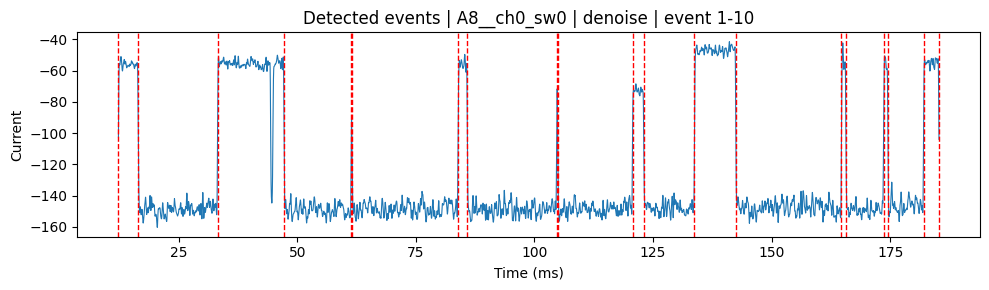

In [11]:
analysis.plot.event_current(sample_id="A8__ch0_sw0", current="denoise", start_event=1, end_event=10)

# Step 3: Feature extract

In [12]:
# feature extraction (support custom feature functions)
def custom_shape_features(seg):
    import numpy as np
    return {'p2p': float(np.max(seg) - np.min(seg)), 'energy': float(np.sum(seg**2)), 'duration': float(len(seg))}

feat_df = analysis.extract_features(custom_feature_fns={'custom': custom_shape_features}, max_event_per_sample=1000)
feat_df.head()

extract_features(samples): 100%|██████████| 4/4 [00:06<00:00,  1.58s/sample, A16__ch1_sw0]


,trace_id,sample_id,channel,sweep,event_id,start_idx,end_idx,start_time_s,end_time_s,duration_s,...,segment_std,segment_min,segment_max,segment_skew,segment_kurt,peak_factor,custom_p2p,custom_energy,custom_duration,label
0,A8__ch0_sw0,A8,0,0,0,1229,1649,0.01229,0.01648,0.00420,...,6.828606,-105.036903,-50.997760,-4.621815,26.412061,1.817705,54.039143,1.402446e+06,420.0,A8
1,A8__ch0_sw0,A8,0,0,1,3318,4722,0.03318,0.04721,0.01404,...,14.829981,-144.713575,-50.120984,-4.572500,23.797319,2.380961,94.592590,5.186579e+06,1404.0,A8
2,A8__ch0_sw0,A8,0,0,2,6138,6152,0.06138,0.06151,0.00014,...,4.635603,-104.947063,-90.535516,-0.535693,1.979909,1.092963,14.411546,1.290797e+05,14.0,A8
3,A8__ch0_sw0,A8,0,0,3,8388,8586,0.08388,0.08585,0.00198,...,10.362797,-106.205649,-49.613810,-2.813885,10.878297,1.762896,56.591839,7.186328e+05,198.0,A8
4,A8__ch0_sw0,A8,0,0,4,10467,10490,0.10467,0.10489,0.00023,...,10.414434,-104.089899,-71.659301,-0.476675,1.899303,1.229115,32.430599,1.649529e+05,23.0,A8


<Axes: title={'center': '2D feature scatter'}, xlabel='blockade_ratio', ylabel='custom_duration (log2)'>

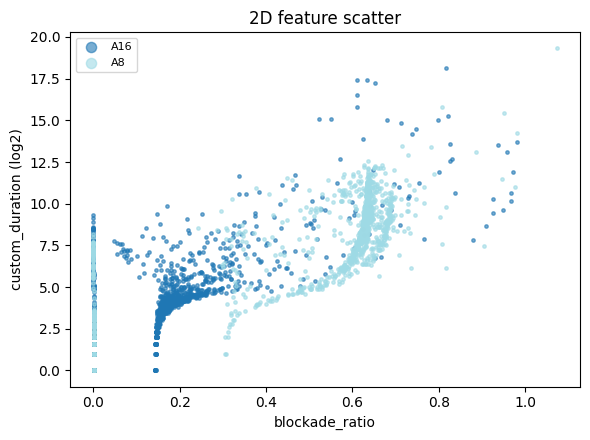

In [13]:
analysis.pl.plot_2d(data='full',
                    x = "blockade_ratio",
                    y = "custom_duration",
                    value='label',
                    x_log2 = False,
                    y_log2 = True,)

# Step 4: events filter

In [14]:
# eveent filtering based on features, defaultly using GMM with blockade_ratio and custom_duration features
analysis.filter_events(method="blockade_gmm",
                       parameters={"n_components": 2, "prior_mean": None},
                       blockage_lim=(0.1, 1.0))
analysis.filtered_df.head()

,trace_id,sample_id,channel,sweep,event_id,start_idx,end_idx,start_time_s,end_time_s,duration_s,...,segment_max,segment_skew,segment_kurt,peak_factor,custom_p2p,custom_energy,custom_duration,label,is_noise,quality_tag
0,A8__ch0_sw0,A8,0,0,0,1229,1649,0.01229,0.01648,0.00420,...,-50.997760,-4.621815,26.412061,1.817705,54.039143,1.402446e+06,420.0,A8,False,valid
1,A8__ch0_sw0,A8,0,0,1,3318,4722,0.03318,0.04721,0.01404,...,-50.120984,-4.572500,23.797319,2.380961,94.592590,5.186579e+06,1404.0,A8,False,valid
3,A8__ch0_sw0,A8,0,0,3,8388,8586,0.08388,0.08585,0.00198,...,-49.613810,-2.813885,10.878297,1.762896,56.591839,7.186328e+05,198.0,A8,False,valid
6,A8__ch0_sw0,A8,0,0,6,13373,14246,0.13373,0.14245,0.00873,...,-41.446233,-6.028505,46.619157,2.126152,60.797189,2.018814e+06,873.0,A8,False,valid
7,A8__ch0_sw0,A8,0,0,7,16471,16567,0.16471,0.16566,0.00096,...,-42.227151,-1.445777,4.626064,1.691756,62.357612,3.668873e+05,96.0,A8,False,valid


In [15]:
from collections import Counter as count
count(analysis.filtered_df.sample_id)

Counter({'A8': 763, 'A16': 746})

<Axes: title={'center': '2D feature scatter'}, xlabel='blockade_ratio', ylabel='custom_duration (log2)'>

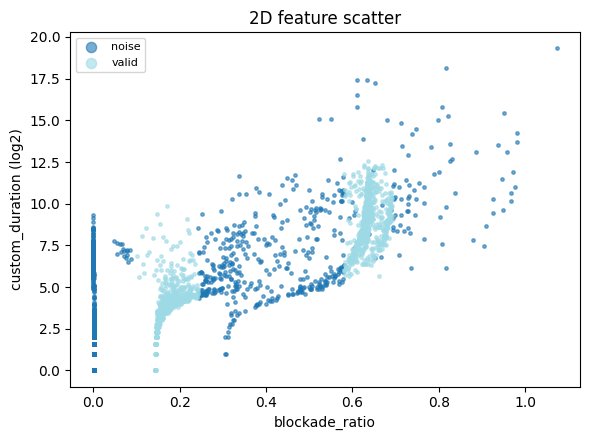

In [16]:
analysis.pl.plot_2d(data='full',
                    x = "blockade_ratio",
                    y = "custom_duration",
                    value='quality_tag',
                    x_log2 = False,
                    y_log2 = True,)

<Axes: title={'center': '2D feature scatter'}, xlabel='blockade_ratio', ylabel='custom_duration (log2)'>

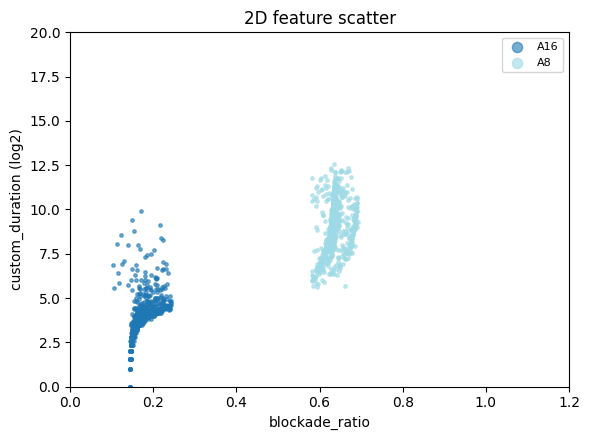

In [17]:
analysis.pl.plot_2d(data='filtered',
                    x = "blockade_ratio",
                    y = "custom_duration",
                    value='label',
                    x_log2 = False,
                    y_log2 = True,
                    xlim=(0, 1.2),
                    ylim=(0, 20))

<Axes3D: title={'center': '3D feature scatter'}, xlabel='blockade_ratio', ylabel='duration_s (log2)', zlabel='segment_std'>

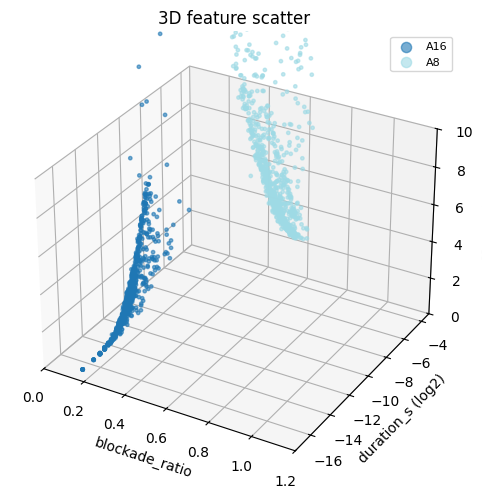

In [18]:
analysis.pl.plot_3d(data='filtered',
                    x = "blockade_ratio",
                    y = "duration_s",
                    value='label',
                    x_log2 = False,
                    y_log2 = True,
                    xlim=(0, 1.2),
                    zlim=(0, 10))

<Axes: title={'center': 'blockade_ratio by label'}, xlabel='label', ylabel='blockade_ratio'>

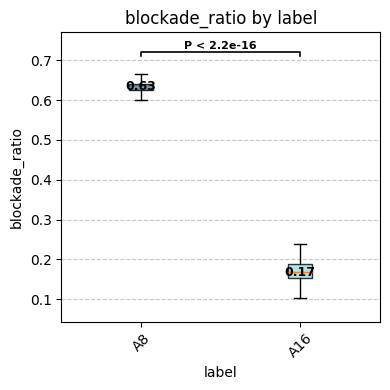

In [19]:
analysis.pl.box_significance(group_col="label", 
                             value_col="blockade_ratio", 
                             data="filtered", 
                             method="ttest",
                             width = 4.0,
                             height = 4.0,)

In [20]:
feature_cols = ["duration_s", "blockade_ratio", "segment_std", "segment_skew", "segment_kurt"]
analysis.do_pca(feature_cols=feature_cols, data="filtered")
#analysis.do_tsne(feature_cols=feature_cols, data="filtered")
#analysis.do_umap(feature_cols=feature_cols, data="filtered")  # 需安装 umap-learn

,trace_id,sample_id,channel,sweep,event_id,start_idx,end_idx,start_time_s,end_time_s,duration_s,...,segment_kurt,peak_factor,custom_p2p,custom_energy,custom_duration,label,is_noise,quality_tag,PC1,PC2
0,A8__ch0_sw0,A8,0,0,0,1229,1649,0.01229,0.01648,0.00420,...,26.412061,1.817705,54.039143,1.402446e+06,420.0,A8,False,valid,11.819907,0.870341
1,A8__ch0_sw0,A8,0,0,1,3318,4722,0.03318,0.04721,0.01404,...,23.797319,2.380961,94.592590,5.186579e+06,1404.0,A8,False,valid,9.427621,8.936142
3,A8__ch0_sw0,A8,0,0,3,8388,8586,0.08388,0.08585,0.00198,...,10.878297,1.762896,56.591839,7.186328e+05,198.0,A8,False,valid,-3.717316,4.805459
6,A8__ch0_sw0,A8,0,0,6,13373,14246,0.13373,0.14245,0.00873,...,46.619157,2.126152,60.797189,2.018814e+06,873.0,A8,False,valid,32.031055,-0.693856
7,A8__ch0_sw0,A8,0,0,7,16471,16567,0.16471,0.16566,0.00096,...,4.626064,1.691756,62.357612,3.668873e+05,96.0,A8,False,valid,-9.962370,9.140334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2992,A16__ch0_sw0,A16,0,0,992,6822882,6822894,68.22882,68.22893,0.00012,...,1.873570,1.024508,5.306739,2.012380e+05,12.0,A16,False,valid,-13.139614,-3.560382
2993,A16__ch0_sw0,A16,0,0,993,6826063,6826078,68.26063,68.26077,0.00015,...,1.945952,1.033402,6.940237,2.489905e+05,15.0,A16,False,valid,-13.054624,-3.143258
2994,A16__ch0_sw0,A16,0,0,994,6827058,6827068,68.27058,68.27067,0.00010,...,1.881499,1.012882,2.831142,1.746787e+05,10.0,A16,False,valid,-13.151316,-4.387303
2996,A16__ch0_sw0,A16,0,0,996,6832801,6832810,68.32801,68.32809,0.00009,...,1.828414,1.005875,1.345298,1.596210e+05,9.0,A16,False,valid,-13.217707,-4.880713


<Axes: title={'center': '2D feature scatter'}, xlabel='PC1', ylabel='PC2'>

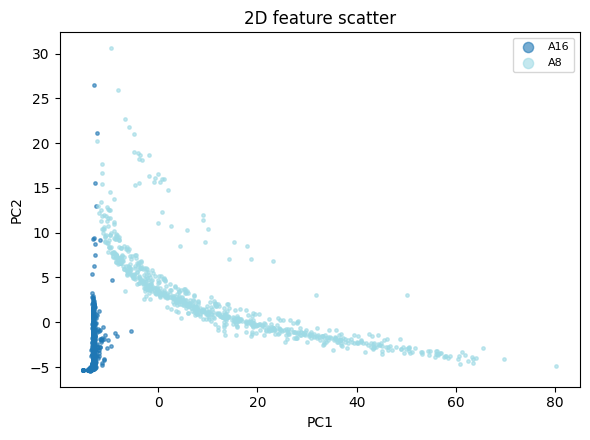

In [21]:
analysis.pl.plot_2d(data='filtered',
                    x = "PC1",
                    y = "PC2",
                    value='label',
                    x_log2 = False,
                    y_log2 = False)

# Step 5: model training

In [22]:
# 10 fold cross validation for model selection
feature_cols = ["duration_s", "blockade_ratio", "segment_std", "segment_skew", "segment_kurt"]
best_pkg = analysis.build_best_model(cv=10, scoring='accuracy', feature_cols=feature_cols)
best_pkg['best_model'], best_pkg['scores']

d:\Software\anaconda3\envs\poremind\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Software\anaconda3\envs\poremind\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Software\anaconda3\envs\poremind\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Software\anaconda3\envs\poremind\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Software\anaconda3\envs\poremind\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Software\anaconda3\envs\poremind\lib\site-packages\s

('Random Forest',
 {'Random Forest': 1.0,
  'Logistic Regression': 0.9973492379058979,
  'SVM': 0.9933730947647449,
  'Neural Network': 1.0,
  'Elastic Net': 0.9966865473823724,
  'Lasso': 0.9966865473823724,
  'Decision Tree': 1.0,
  'LDA': 1.0,
  'AdaBoost': 1.0,
  'Naive Bayes': 1.0})

<Axes: title={'center': 'Random Forest | test confusion matrix (%)'}, xlabel='Predicted', ylabel='True'>

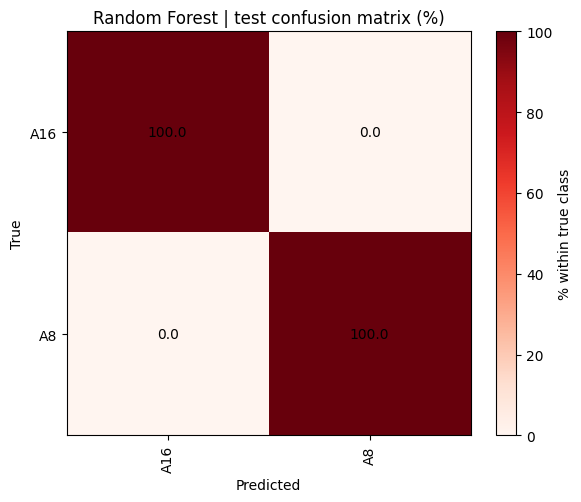

In [23]:
# confusion matrix for the best model on the test set
analysis.pl.model_cm(model_name=best_pkg['best_model'], split='test')

<Axes: title={'center': 'Model comparison | test_accuracy_weighted'}, ylabel='test_accuracy_weighted'>

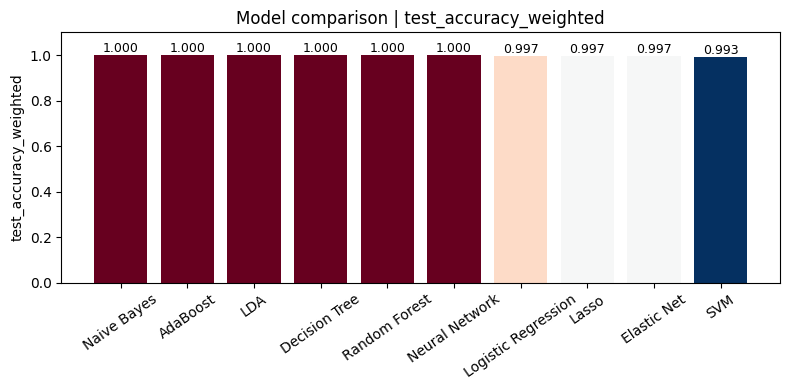

In [24]:
# plot the model metric for different models on the test set
analysis.pl.model_metric_bar(metric='accuracy', split='test')

In [29]:
analysis.model_cv_results.keys()

dict_keys(['Random Forest', 'Logistic Regression', 'SVM', 'Neural Network', 'Elastic Net', 'Lasso', 'Decision Tree', 'LDA', 'AdaBoost', 'Naive Bayes'])

In [25]:
best_pkg.keys()

dict_keys(['model', 'feature_cols', 'scores', 'best_model', 'models', 'cv_results', 'all_samples_feature_pred', 'preprocess_state', 'detect_state', 'feature_state'])

In [26]:
best_pkg["cv_results"]

{'Random Forest': {'folds': [{'fold': 1,
    'train_n': 1358,
    'test_n': 151,
    'train_f1': 1.0,
    'train_accuracy': 1.0,
    'train_recall': 1.0,
    'test_f1': 1.0,
    'test_accuracy': 1.0,
    'test_recall': 1.0,
    'train_cm': array([[672,   0],
           [  0, 686]]),
    'test_cm': array([[74,  0],
           [ 0, 77]]),
    'fit_error': None},
   {'fold': 2,
    'train_n': 1358,
    'test_n': 151,
    'train_f1': 1.0,
    'train_accuracy': 1.0,
    'train_recall': 1.0,
    'test_f1': 1.0,
    'test_accuracy': 1.0,
    'test_recall': 1.0,
    'train_cm': array([[672,   0],
           [  0, 686]]),
    'test_cm': array([[74,  0],
           [ 0, 77]]),
    'fit_error': None},
   {'fold': 3,
    'train_n': 1358,
    'test_n': 151,
    'train_f1': 1.0,
    'train_accuracy': 1.0,
    'train_recall': 1.0,
    'test_f1': 1.0,
    'test_accuracy': 1.0,
    'test_recall': 1.0,
    'train_cm': array([[672,   0],
           [  0, 686]]),
    'test_cm': array([[74,  0],
          

In [27]:
best_pkg["feature_cols"]

['duration_s', 'blockade_ratio', 'segment_std', 'segment_skew', 'segment_kurt']

In [28]:
best_pkg["all_samples_feature_pred"]

,trace_id,sample_id,label,duration_s,blockade_ratio,segment_std,segment_skew,segment_kurt,best_model_pred
0,A8__ch0_sw0,A8,A8,0.00420,0.625491,6.828606,-4.621815,26.412061,A8
1,A8__ch0_sw0,A8,A8,0.01404,0.615296,14.829981,-4.572500,23.797319,A8
2,A8__ch0_sw0,A8,A8,0.00014,0.374026,4.635603,-0.535693,1.979909,A16
3,A8__ch0_sw0,A8,A8,0.00198,0.612656,10.362797,-2.813885,10.878297,A8
4,A8__ch0_sw0,A8,A8,0.00023,0.451464,10.414434,-0.476675,1.899303,A8
...,...,...,...,...,...,...,...,...,...
3995,A16__ch1_sw0,A16,A16,0.00007,0.000831,0.000855,-0.389151,1.620216,A16
3996,A16__ch1_sw0,A16,A16,0.00005,0.000811,0.000572,-0.267082,1.280141,A16
3997,A16__ch1_sw0,A16,A16,0.00009,0.000850,0.001327,-0.519819,1.922746,A16
3998,A16__ch1_sw0,A16,A16,0.00001,0.000764,0.000000,0.000000,0.000000,A16


# Setp 5.1: model training (neural network)

In [32]:
# need torch: pip install torch
dl_pkg = analysis.build_DL_model(model=None, # defaultly using 1D-CNN
                                 model_name="1D-CNN", 
                                 device="cuda", 
                                 interp_length=500,
                                 expand=50,
                                 scale="mad",
                                 epoch=30, 
                                 batch_size=64,
                                 learning_rate=1e-4,
                                 early_stop_patience=5,)

<Axes: title={'center': 'Fold train loss curves (normalized) | 1D-CNN'}, xlabel='Epoch', ylabel='Normalized Loss'>

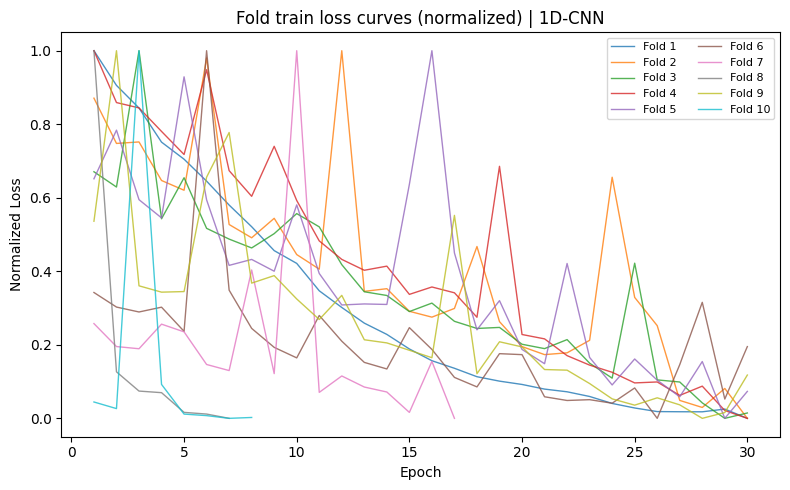

In [33]:
analysis.pl.plot_fold_loss(model_name="1D-CNN")

In [41]:
loss = analysis.model_cv_results["1D-CNN"].get("fold_losses").copy()
loss[0].keys(), len(loss)

(dict_keys(['train_loss', 'val_loss']), 10)

<Axes: title={'center': 'Model comparison | test_accuracy_weighted'}, ylabel='test_accuracy_weighted'>

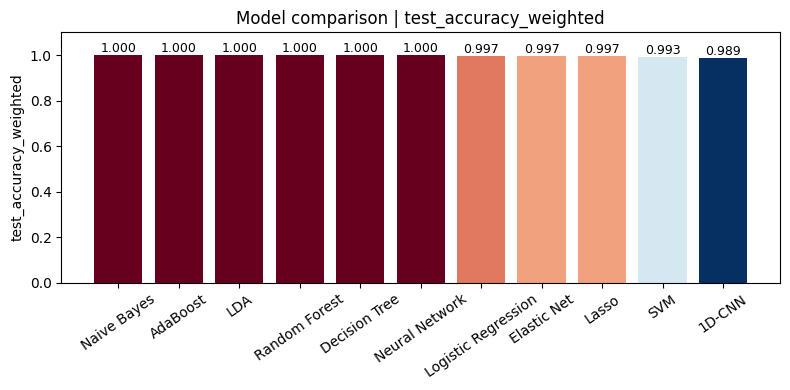

In [42]:
# plot the model metric for different models on the test set
analysis.pl.model_metric_bar(metric='accuracy', split='test')

In [43]:
dl_pkg

{'model_name': '1D-CNN',
 'model': ModuleDict(
   (extractor): DefaultConvExtractor(
     (net): Sequential(
       (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
       (1): ReLU()
       (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
       (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
       (4): ReLU()
       (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
       (6): AdaptiveAvgPool1d(output_size=1)
       (7): Flatten(start_dim=1, end_dim=-1)
       (8): Linear(in_features=32, out_features=10, bias=True)
       (9): ReLU()
     )
   )
   (head): Linear(in_features=15, out_features=2, bias=True)
 ),
 'model_state_dict': {'extractor.net.0.weight': tensor([[[ 0.3841, -0.0118,  0.1886, -0.3017, -0.1629,  0.0746, -0.2949]],
  
          [[ 0.2877,  0.2649, -0.3033,  0.0016, -0.1540,  0.0851, -0.1085]],
  
          [[ 0.3124,  0.0423,  0.1462, -0.0746, -0.2047,  0.3732, -0.1076]],
  
 

In [44]:
analysis.filtered_df[["trace_id", "event_id", "pred_label_1D-CNN", "pred_proba_A16_1D-CNN", "pred_proba_A8_1D-CNN"]].head()

,trace_id,event_id,pred_label_1D-CNN,pred_proba_A16_1D-CNN,pred_proba_A8_1D-CNN
0,A8__ch0_sw0,0,A8,8.391871e-07,0.999999
1,A8__ch0_sw0,1,A8,4.609990e-07,1.000000
3,A8__ch0_sw0,3,A8,7.371742e-04,0.999263
6,A8__ch0_sw0,6,A8,9.299362e-08,1.000000
7,A8__ch0_sw0,7,A8,1.718188e-01,0.828181


# Step 6: new sample classify

In [50]:
new_paths = {'unknown_01': 'example_data\A16_20240410_0012.abf',}
new_analysis, pred = analysis.classify_new_samples(new_paths, 
                                                   model="Naive Bayes",
                                                   custom_feature_fns={'custom': custom_shape_features}, 
                                                   reader='abf')
pred[['sample_id', 'event_id', 'start_time_s', 'end_time_s']+[col for col in pred.columns if 'pred' in col]].head()

extract_features(samples): 100%|██████████| 2/2 [00:43<00:00, 21.69s/sample, unknown_01__ch1_sw0]


,sample_id,event_id,start_time_s,end_time_s,pred_label,pred_proba_A16,pred_proba_A8
0,unknown_01,0,0.00000,0.26879,A8,0.0,1.0
1,unknown_01,1,0.42557,0.76103,A8,0.0,1.0
2,unknown_01,2,1.21961,1.42283,A8,0.0,1.0
3,unknown_01,3,1.59630,1.66440,A8,0.0,1.0
4,unknown_01,4,1.76237,1.78908,A8,0.0,1.0


In [51]:
new_analysis.feature_df.columns

Index(['trace_id', 'sample_id', 'channel', 'sweep', 'event_id', 'start_idx',
       'end_idx', 'start_time_s', 'end_time_s', 'duration_s', 'delta_i', 'snr',
       'left_baseline', 'right_baseline', 'global_baseline', 'blockade_ratio',
       'segment_mean', 'segment_std', 'segment_min', 'segment_max',
       'segment_skew', 'segment_kurt', 'peak_factor', 'custom_p2p',
       'custom_energy', 'custom_duration', 'pred_label', 'pred_proba_A16',
       'pred_proba_A8'],
      dtype='object')

<Axes: title={'center': '2D feature scatter'}, xlabel='blockade_ratio', ylabel='duration_s (log2)'>

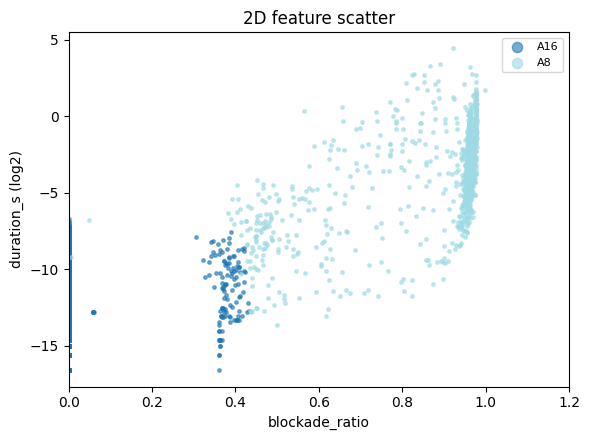

In [52]:
new_analysis.pl.plot_2d(data='full',
                    x = "blockade_ratio",
                    y = "duration_s",
                    value='pred_label',
                    x_log2 = False,
                    y_log2 = True,
                    xlim=(0, 1.2))

<Axes: title={'center': '2D feature scatter'}, xlabel='blockade_ratio', ylabel='duration_s (log2)'>

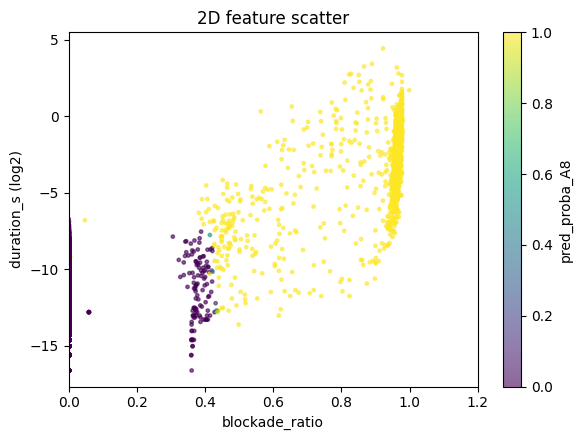

In [53]:
new_analysis.pl.plot_2d(data='full',
                    x = "blockade_ratio",
                    y = "duration_s",
                    value='pred_proba_A8',
                    x_log2 = False,
                    y_log2 = True,
                    xlim=(0, 1.2))

<Axes3D: title={'center': '3D feature scatter'}, xlabel='blockade_ratio', ylabel='duration_s (log2)', zlabel='segment_std'>

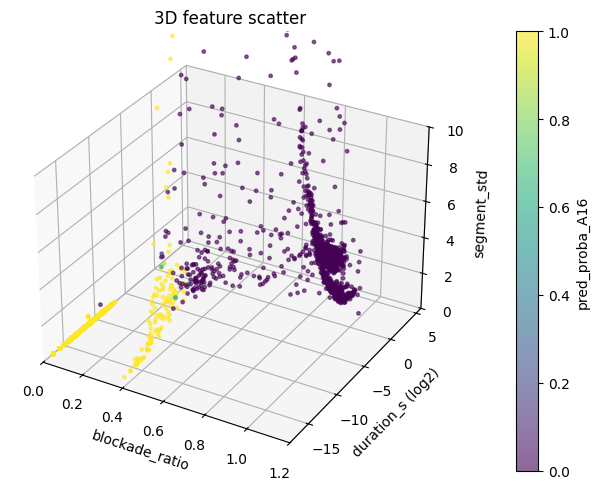

In [62]:
new_analysis.pl.plot_3d(data='full',
                    x = "blockade_ratio",
                    y = "duration_s",
                    value='pred_proba_A8',
                    x_log2 = False,
                    y_log2 = True,
                    xlim=(0, 1.2),
                    zlim=(0, 10))

<Axes: title={'center': 'Detected events (pred_label) | unknown_01__ch0_sw0 | denoise | event 1-10'}, xlabel='Time (ms)', ylabel='Current'>

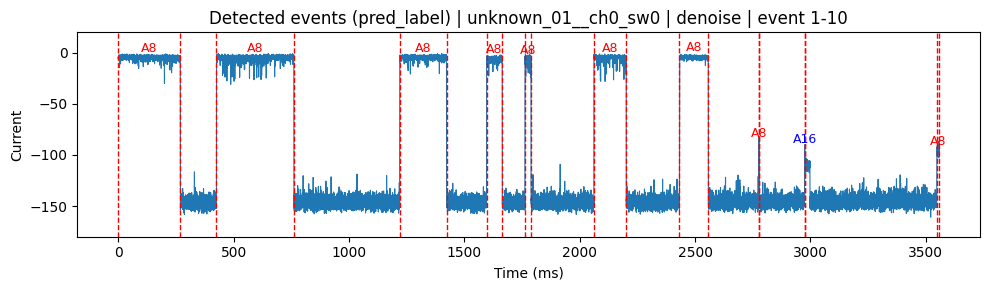

In [55]:
new_analysis.pl.event_current_label(sample_id="unknown_01__ch0_sw0", 
                                    current="denoise", 
                                    lable_col='pred_label',
                                    label_size=9,
                                    lable_color={"A8": "red", "A16": "blue"},
                                    label_offset=3,
                                    ylim=(-180, 20),
                                    start_event=1, 
                                    end_event=10)

In [61]:
new_analysis.feature_df.pred_label.value_counts()

pred_label
A16    43177
A8      1210
Name: count, dtype: int64

<Axes: title={'center': 'Stacked proportion: pred_label by sample_id'}, xlabel='sample_id', ylabel='Proportion'>

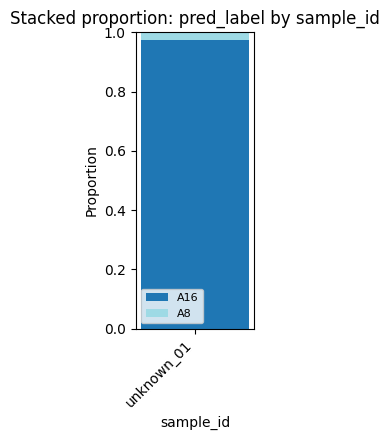

In [60]:
new_analysis.pl.stacked_bar(group_col="sample_id", 
                            value_col="pred_label",
                            width = 2.0,
                            height = 4.5,)